<a href="https://colab.research.google.com/github/Carlos-Martinez-30/telecom-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print('Valores nulos\n',users.isnull().sum())# Cantidad de valores nulos
print('Proporcion\n',users.isnull().mean())# Proporción de valores nulos

Valores nulos
 user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporcion
 user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Indica qué harías: ¿imputar, eliminar, ignorar?
  City es una columna con 11.7 de valores faltantes, se puede imputar la ciudad mas frecuente
  Churn_date tiene 88.35 no creo que convenga eliminar es mejor mantener los registros de quienes si se dieron de baja

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.

El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users[['user_id','age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
  la columna es consistente
- La columna `age` ...
  la columna tiene el valor minimo de -999 esa edad es imposible, esto afecta la desviacion estandar 123

In [ ]:
# explorar columnas numéricas de usage
usage[['id','user_id']].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ambas, se ven homogeneas y sin anomalias

In [ ]:
# explorar columnas categóricas de users
users[['city', 'plan']].describe()


,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` el top es Bogota con 808 apariciones
  con 7 ciudades diferentes el conteo me parece elevado...
- La columna `plan` basico tiene mas del 60% de los usuarios ...

In [ ]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` muestra que los mensajes de texto
  tienen mayor frecuencia que las llamadas...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  En users['edad'] hay edades -999
- ¿Qué acción tomarías?
    reemplazarlos por la mediana

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [ ]:
# Revisar los años presentes en `reg_date` de users


years = users['reg_date'].dt.year.dropna()
print(years.value_counts())



2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
Valores muy parecidos del 2022 al 2024 no hay 2025 pero si 2026, por lo que  revisaria las fechas del 2026

In [ ]:
# Revisar los años presentes en `date` de usage
years = usage['date'].dt.year.dropna()
print(years.value_counts())


2024.0    39950
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas. a pesar de haber convertido la columna a fecha el formato que me arroja es el de un numero 2024.0

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
si,
los podria remplazar por el formato correcto  o en su defecto las fechas del 2026 reemplazarlas con valores nulos temporales

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age']!= -999,'age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?',pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:
# Marcar fechas futuras como NA para reg_date
users['reg_date']= pd.to_datetime(users['reg_date'],errors='coerce')
current_year= pd.Timestamp.today().year
users.loc[users['reg_date'].dt.year>current_year, 'reg_date']= pd.NaT
# Verificar cambios
print(users['reg_date'].isna().sum())

0


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration_missing']= usage['duration'].isna()
print(usage.groupby(type)['duration_missing'].mean())

<class 'int'>    0.5519
Name: duration_missing, dtype: float64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length_missing']= usage['length'].isna()
print(usage.groupby(type)['length_missing'].mean())


<class 'int'>    0.4474
Name: length_missing, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`


El porcentaje de nulos varia segun la categoria type, los datos faltantes dependen de esa variable, los nulos de `duration` y `length` son MAR (Missing At Random )

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg =(usage.groupby('user_id').agg(
    total_messages=('is_text','sum'),
    total_calls=('is_call',"sum"),
    total_call_minutes=('duration','sum')
).reset_index())

# observar resultado
usage_agg.head(3)


,user_id,total_messages,total_calls,total_call_minutes
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas

# observar resultado
usage_agg.head(3)

,user_id,total_messages,total_calls,total_call_minutes
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile =users.merge(
    usage_agg,
    on='user_id',
    how='left'
)
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_messages,total_calls,total_call_minutes
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
users.describe(include='number')

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,48.136000
std,1154.844867,17.689919
min,10000.000000,18.000000
25%,10999.750000,33.000000
50%,11999.500000,48.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [ ]:
# Distribución porcentual del tipo de plan
users['plan'].value_counts(normalize=True)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

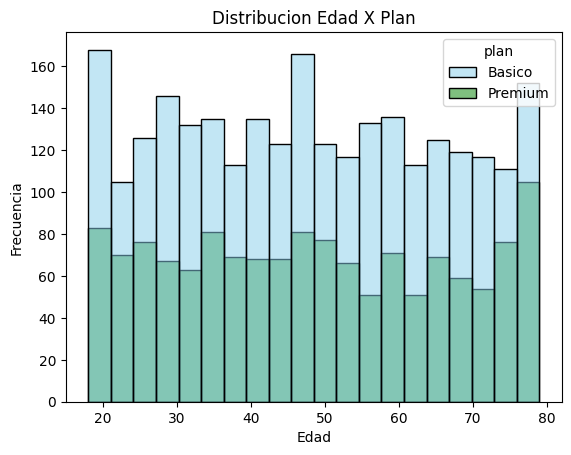

In [ ]:
# Histograma para visualizar la edad (age)


sbn.histplot(data= users, x='age',hue = 'plan', palette =['skyblue','green'], kde=False, bins=20 )
plt.title('Distribucion Edad X Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()



💡Insights:
- Distribución simetrica, no hay una tendencia clara hacia alguno de los planes, tanto jovenes como mayores estan distribuidos de forma similar en ambos planes

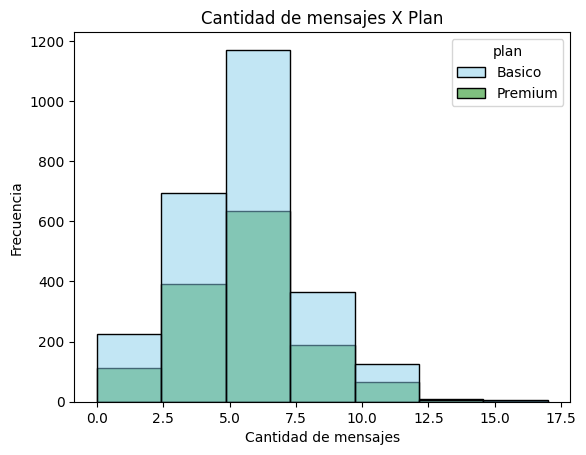

In [ ]:

# Histograma para visualizar la cant_mensajes

usage_join = users.merge(usage_agg, on="user_id", how="left")

sbn.histplot(data= usage_join,x='total_messages',hue = 'plan', palette =['skyblue','green'], kde=False, bins=7)
plt.title('Cantidad de mensajes X Plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()






💡Insights:
- Se puede observar sesgo hacia la derecha, en ambos planes a partir de los 8 mensajes, los usuarios de plan basico tienden a enviar mas mensajes en promedio, solo muy pocos son altamente activos
    

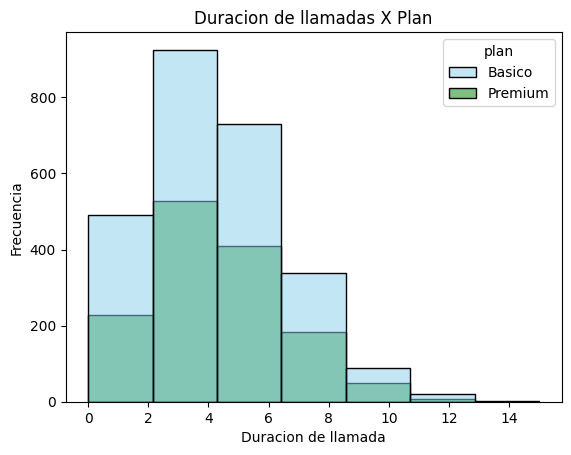

In [ ]:
# Histograma para visualizar la cant_llamadas


usage_join = users.merge(usage_agg, on="user_id", how="left")

sbn.histplot(data= usage_join,x='total_calls',hue = 'plan', palette =['skyblue','green'], kde=False, bins=7)

plt.title('Duracion de llamadas X Plan')
plt.xlabel('Duracion de llamada')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
- Distribución sesgada a la derecha, a partir de 6 llamadas la frecuencia cae rapidamente para ambos planes, lo que indica que pocos usuarios hacen muchas llamadas

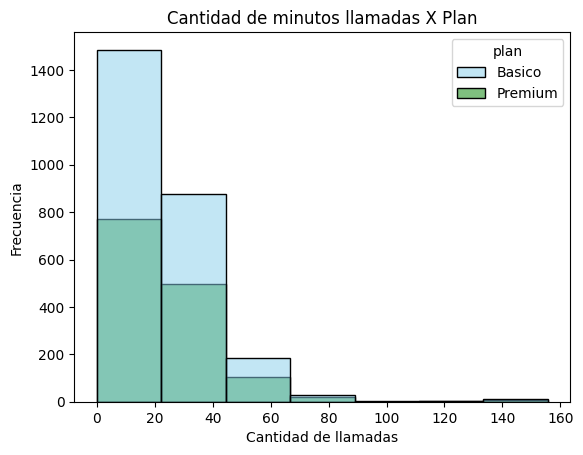

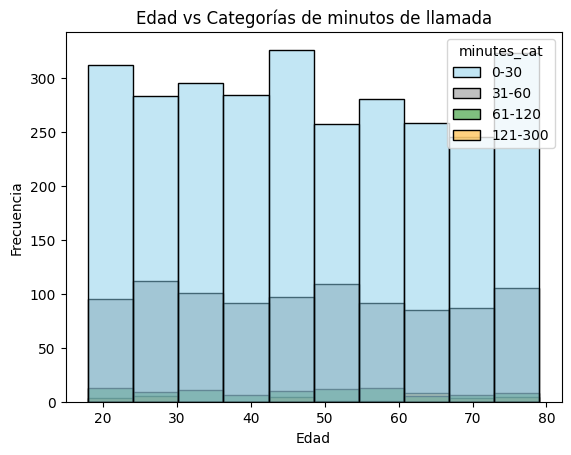

In [ ]:
# Histograma para visualizar la cant_minutos_llamada

usage_join = users.merge(usage_agg, on="user_id", how="left")

sbn.histplot(data= usage_join,x='total_call_minutes',hue = 'plan', palette =['skyblue','green'], kde=False, bins=7)
plt.title('Cantidad de minutos llamadas X Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

# Crear categorías de minutos
usage_join['minutes_cat'] = pd.cut(
    usage_join['total_call_minutes'],
    bins=[0, 30, 60, 120, 300],
    labels=['0-30', '31-60', '61-120', '121-300']
)

sbn.histplot(
    data=usage_join,
    x='age',
    hue='minutes_cat',
    palette=['skyblue','grey','green','orange'],
    bins=10
)
plt.title('Edad vs Categorías de minutos de llamada')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
-Independientemente de la edad, la mayoria de los usuarios realiza llamadas breves de menos de 30 minutos, la distribucion es uniforme por edad, pero segada a hacia llamadas cortas en todas las categorias

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

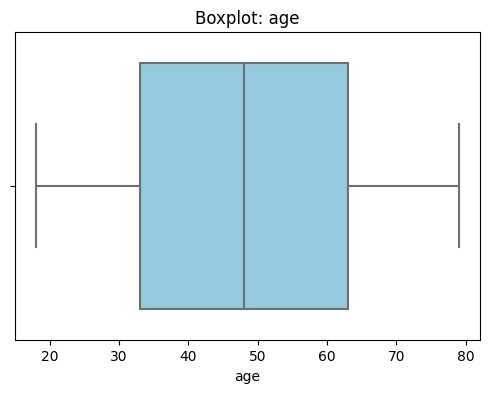

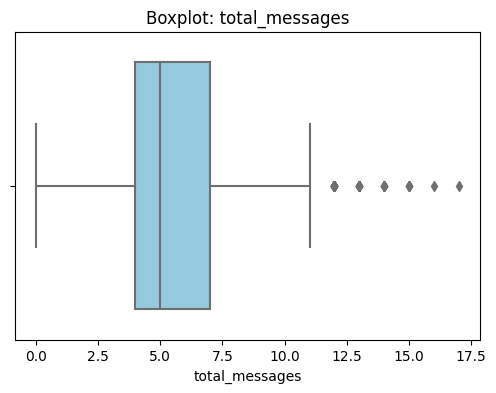

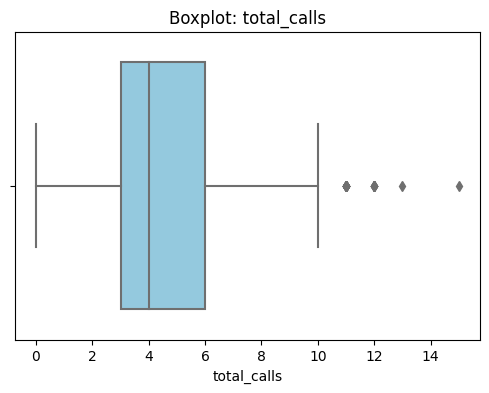

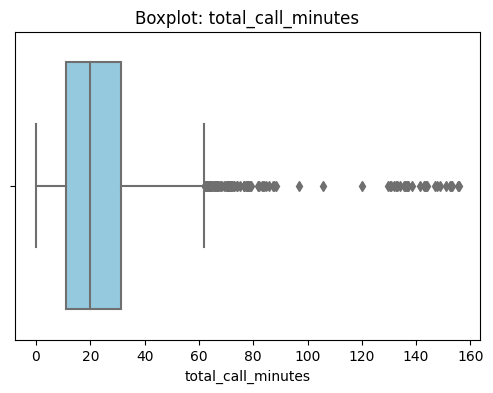

      user_id first_name last_name   age      city  \
27      10027        Ana     Gomez  28.0       MTY   
85      10085     Carlos   Ramirez  65.0       GDL   
93      10093        Ana    Torres  67.0  Medellín   
189     10189    Mariana    Torres  63.0       MTY   
198     10198      Sofia     Gomez  58.0  Medellín   
...       ...        ...       ...   ...       ...   
3920    13920    Mariana     Lopez  48.0    Bogotá   
3927    13927    Mariana     Lopez  18.0       GDL   
3945    13945       Luis   Ramirez  30.0    Bogotá   
3953    13953      Mateo     Gomez  58.0       GDL   
3967    13967     Carlos    Torres  72.0  Medellín   

                          reg_date     plan   churn_date  total_messages  \
27   2022-01-08 09:26:03.690922730  Premium          NaN             8.0   
85   2022-01-24 06:35:22.730682670   Basico          NaN             6.0   
93   2022-01-26 11:09:46.046511628   Basico          NaN             2.0   
189  2022-02-21 18:02:25.836459115   Basico    

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = [ 'age','total_messages', 'total_calls', 'total_call_minutes']

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sbn.boxplot(data=usage_join,x=col,color="skyblue")
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

Q1 = user_profile[col].quantile(0.25)
Q3 = user_profile[col].quantile(0.75)
IQR = Q3 - Q1
outliers = user_profile[(user_profile[col] < Q1 - 1.5*IQR) | (user_profile[col] > Q3 + 1.5*IQR)]
print(outliers)

💡Insights:
- Age: No presenta puntos fuera de los bigotes, la distribucion de edades es bastante homogenea
- cant_mensajes: si hay varios punto a la derecha, varios usuarios envian mensajes significativamente mayor al promedio
- cant_llamadas: si hay varios puntos a la derecha, hay muchos usuarios que realizan muchas llamadas a comparacion del resto
- cant_minutos_llamada: si es el que muestra mas puntos a la derecha, hay usuarios con tiempos de llamada muy altos, casos atipicos  

In [ ]:


# Calcular límites con el método IQR
columnas_limites = usage_join[['age','total_messages', 'total_calls', 'total_call_minutes']]

for col in columnas_limites:
    Q1 = columnas_limites[col].quantile(0.25)
    Q3 = columnas_limites[col].quantile(0.75)
    IQR =Q3-Q1
    # calcular límite inferior y superior
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print()
    print(col)
    print("Limite Inferiror ", lower)
    print("Limite Superior ", upper)



age
Limite Inferiror  -12.0
Limite Superior  108.0

total_messages
Limite Inferiror  -0.5
Limite Superior  11.5

total_calls
Limite Inferiror  -1.5
Limite Superior  10.5

total_call_minutes
Limite Inferiror  -19.322500000000005
Limite Superior  61.8575


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
columnas_limites.describe()

,age,total_messages,total_calls,total_call_minutes
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
  
Aunque el maximo 17 supera el limite de 11.5 la desviacion estandar es moderada lo que puede sugerir usuarios muy activos, no errores
- cant_llamadas: mantener o no outliers, porqué?

El maximo 15 tambien excede el limite 10.5, pero la distribucion es similar a la de mensajes, puede haber usuarios muy activos
- cant_minutos_llamada: mantener o no outliers, porqué?

 Aqui el maximo es mas del doble del limite superior y la desviacion estandar es alta eliminar o recortar los outliers extremos es la accion recomendada, pues podrian ser errores de registro o casos atipicos

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso


def clasificacion_uso(row):
    llamadas = row['total_calls']
    mensajes = row['total_messages']

    if (llamadas < 5) and (mensajes < 5):
        return 'Bajo uso'

    elif (llamadas < 10) and (mensajes < 10):
        return 'Uso medio'

    else:
        return 'Alto uso'
user_profile['grupo_uso'] = user_profile.apply(clasificacion_uso, axis=1)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_messages,total_calls,total_call_minutes,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad

def clasificacion_edad(row):
    edad = row['age']   # esta línea debe estar dentro de la función

    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# Crear la nueva columna
user_profile['grupo_edad'] = user_profile.apply(clasificacion_edad, axis=1)



In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_messages,total_calls,total_call_minutes,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


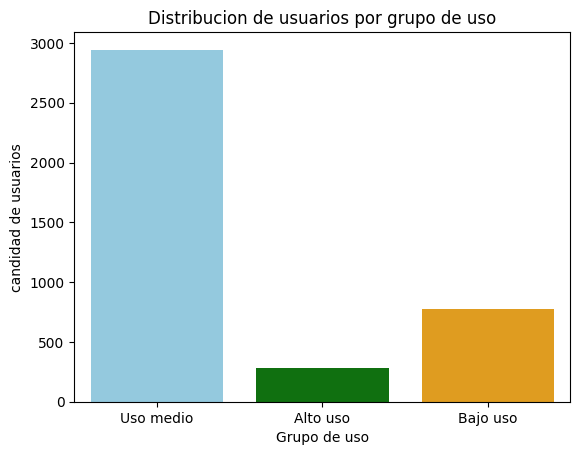

In [ ]:
# Visualización de los segmentos por uso
sbn.countplot(data=user_profile, x='grupo_uso', palette=['skyblue','green','orange'])
plt.title('Distribucion de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('candidad de usuarios')
plt.show()

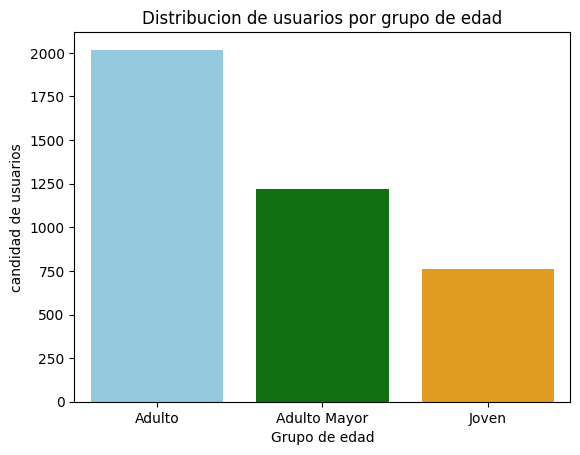

In [ ]:
# Visualización de los segmentos por edad
sbn.countplot(data=user_profile, x='grupo_edad', palette=['skyblue','green','orange'])
plt.title('Distribucion de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('candidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Valores nulos y sentinels. La columna age contenia valores como -999, que representaban datos faltantes
- Aproximadamente 12% de los registros tenian valores nulos o invalidos en city, y cerca del 5% en age.


🔍 **Segmentos por Edad**
- Joven <30 años Menor proporcion, uso irregular mas enfocado en datos moviles,potencial para planes de datos y servicios digitales
- Adulto 30-59 años Segmento dominante, uso constante , fidelidad representa el nucleo del negocio, con comportamiento predecible y baja tasa de abandono
- Adulto mayor >= 60 años Uso mas bajo, pero estable, son clientes rentables por su consumo y menor sensibilidad al precio
   


📊 **Segmentos por Nivel de Uso**
- Bajo uso Usuarios con minima interacion,
- Uso medio Mayoria del publico uso equilibrado y estable
- Alto uso usuarios, con alto sonsumo de minutos y mensajes


➡️ Se detectaron outliers hacia valores altos en total_messages, total_calls y total_call_minutes lo que implica un grupo reducido de usuarios hevy users que podrian estar en planes inadecuados o subestimados en costo


💡 **Recomendaciones**
- Crear planes comerciales como un plan intermedio flexible para el grupo "uso medio" para capturar el segmento mas grande y estable
- Promover paquetes de datos y redes para ataer nuevos clientes
- Implementar alertas automaticas para detectar sonsumo anomalo para prevenir fraudes y optimizar recursos de red

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`